<center><image src="https://drive.google.com/uc?id=1n3G4TdK_u6PQHcLrxB_A0HijNdigXmUH">

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Сегментация изображений</b></h3>


В этом задании вам предстоит решить задачу сегментации медицинских снимков. Домашнее задание можно разделить на следующие части:

* Построй свой первый бейзлайн! [6]
  * BCE Loss [2]
  * SegNet [2]
  * Train [1]
  * Test [1]
* Мир других лоссов! [2]
  * Dice Loss [1]
  * Focal Loss [1]
  * BONUS: лосс из статьи [5]
* Новая модель! [2]
  * UNet [2]


**Максимальный балл:** 10 баллов.

Также для студентов желающих еще более углубиться в задачу предлагается решить бонусное задание, которое даст дополнительные 5 баллов. BONUS задание необязательное.


# Шаг 1. Загрузка и подготовка данных

1. Для начала мы скачаем датасет: [ADDI project](https://www.fc.up.pt/addi/ph2%20database.html).

<table><tr><td>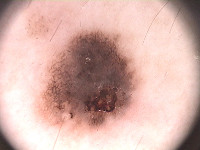</td><td>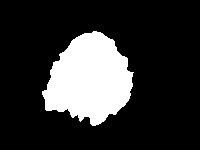</td></tr></table>

2. Разархивируем .rar файл.
3. Обратите внимание, что папка  `PH2 Dataset images` должна лежать там же где и ipynb notebook.

Это фотографии двух типов **поражений кожи:** меланома и родинки.
В данном задании мы не будем заниматься их классификацией, а будем **сегментировать** их.

In [1]:
!gdown 1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql

Downloading...
From (original): https://drive.google.com/uc?id=1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql
From (redirected): https://drive.google.com/uc?id=1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql&confirm=t&uuid=93fa2e0a-5d3d-4c46-8d75-b6b634d955e0
To: /content/PH2Dataset.rar
100% 162M/162M [00:01<00:00, 119MB/s]


In [2]:
get_ipython().system_raw("unrar x PH2Dataset.rar")

Стуктура датасета у нас следующая:

    IMD_002/
        IMD002_Dermoscopic_Image/
            IMD002.bmp
        IMD002_lesion/
            IMD002_lesion.bmp
        IMD002_roi/
            ...
    IMD_003/
        ...
        ...

 Здесь `X.bmp` — изображение, которое нужно сегментировать, `X_lesion.bmp` — результат сегментации.

Для загрузки датасета можно использовать skimage: [`skimage.io.imread()`](https://scikit-image.org/docs/dev/api/skimage.io.html)

In [3]:
images = []
lesions = []
from skimage.io import imread
import os
root = 'PH2Dataset'

for root, dirs, files in os.walk(os.path.join(root, 'PH2 Dataset images')):
    if root.endswith('_Dermoscopic_Image'):
        images.append(imread(os.path.join(root, files[0])))
    if root.endswith('_lesion'):
        lesions.append(imread(os.path.join(root, files[0])))

Изображения имеют разные размеры. Давайте изменим их размер на $256\times256 $ пикселей. Для изменения размера изображений можно использовать [`skimage.transform.resize()`](https://scikit-image.org/docs/dev/api/skimage.transform.html#skimage.transform.resize).
Эта функция также автоматически нормализует изображения в диапазоне $[0,1]$.


In [4]:
from skimage.transform import resize
size = (256, 256)
X = [resize(x, size, mode='constant', anti_aliasing=True,) for x in images]
Y = [resize(y, size, mode='constant', anti_aliasing=False) > 0.5 for y in lesions]

In [5]:
import numpy as np
X = np.array(X, np.float32)
Y = np.array(Y, np.float32)
print(f'Loaded {len(X)} images')

Loaded 200 images


Чтобы убедиться, что все корректно, мы нарисуем несколько изображений

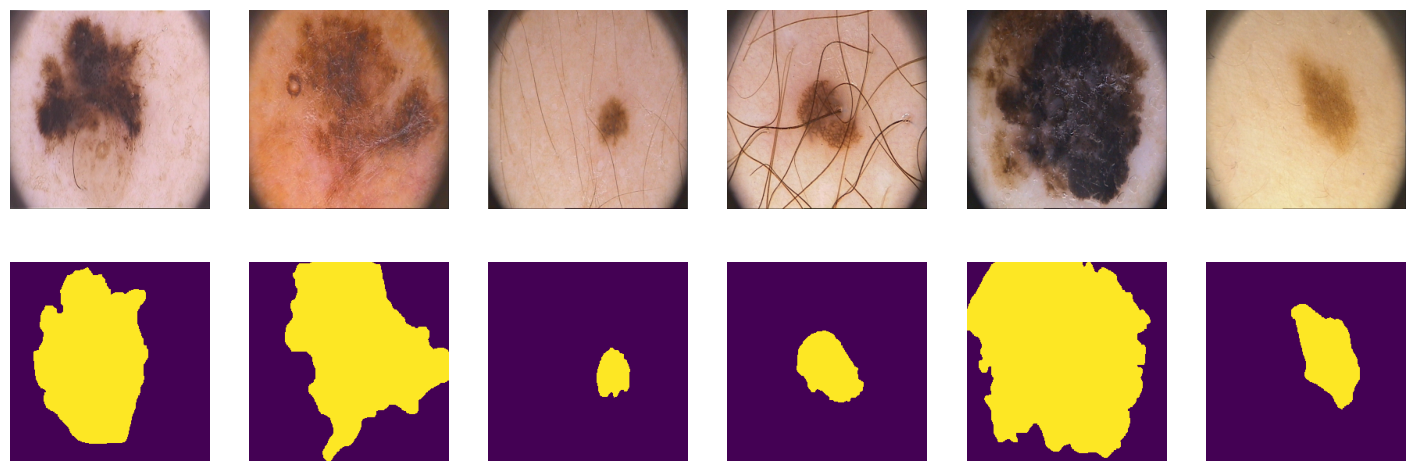

In [6]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

plt.figure(figsize=(18, 6))
for i in range(6):
    plt.subplot(2, 6, i+1)
    plt.axis("off")
    plt.imshow(X[i])

    plt.subplot(2, 6, i+7)
    plt.axis("off")
    plt.imshow(Y[i])
plt.show();

Разделим наши 200 картинок на 100/50/50
 для обучения, валидации и теста соответственно

In [7]:
ix = np.random.choice(len(X), len(X), False)
tr, val, ts = np.split(ix, [100, 150])

In [8]:
print(len(tr), len(val), len(ts))

100 50 50


## PyTorch DataLoader

In [9]:
from torch.utils.data import DataLoader
batch_size = 25
train_dataloader = DataLoader(list(zip(np.rollaxis(X[tr], 3, 1), Y[tr, np.newaxis])),
                     batch_size=batch_size, shuffle=True)
valid_dataloader = DataLoader(list(zip(np.rollaxis(X[val], 3, 1), Y[val, np.newaxis])),
                      batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(list(zip(np.rollaxis(X[ts], 3, 1), Y[ts, np.newaxis])),
                     batch_size=batch_size, shuffle=False)

In [10]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


# Шаг 2. Метрика качества модели

## IoU (intersection over union)

В данном разделе предлагается использовать следующую метрику для оценки качества:

$I o U=\frac{\text {target } \cap \text { prediction }}{\text {target } \cup{prediction }}$

Пересечение (A ∩ B) состоит из пикселей, найденных как в маске предсказания, так и в основной маске истины, тогда как объединение (A ∪ B) просто состоит из всех пикселей, найденных либо в маске предсказания, либо в целевой маске.


Что будет являться пересением и объединением в задаче сегментации?

Давайте разберем следующий пример:





<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1rBYFgli48AUUN9idiyq8j3J5DboB93yN" width=1000 height=800/></p>

In [11]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 25.4 MB/s eta 0:00:00


In [12]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [13]:
from torchmetrics import JaccardIndex

iou_score = JaccardIndex(threshold=0.5, task="binary", average='none').to(device)

# Задания: Построй свой первый бейзлайн!

Итак, загрузка файлов, код датасета и даталоадера написана за вас. Метрика IoU написана за вас! Вам остается написать лосс, модель и функции обучения и теста модели.

* Построй свой первый бейзлайн! [6]
  * BCE Loss [2]
  * SegNet [2]
  * Train [1]
  * Test [1]

## Шаг 3. Loss функция - BCE [2 балла]

Популярным лоссом для бинарной сегментации является *бинарная кросс-энтропия*, которая задается следующим образом:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right] \space [1]$$

где $y$ это  таргет желаемого результата и $\hat y$ является выходом модели. $\sigma$ - это [*логистическая* функция](https://en.wikipedia.org/wiki/Sigmoid_function), который преобразует действительное число $\mathbb R$ в вероятность $[0,1]$.

Однако эта потеря страдает от проблем численной нестабильности. Самое главное, что $\lim_{x\rightarrow0}\log(x)=\infty$ приводит к неустойчивости в процессе оптимизации. Рекомендуется посмотреть следующее [упрощение](https://www.tensorflow.org/api_docs/python/tf/nn/sigmoid_cross_entropy_with_logits). Эта функция эквивалентна первой и не так подвержена численной неустойчивости:

$$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right) \space [2]$$

### Вывод численно стабильной формулы BCE лосса [1 балл]



Выведите из формулы [1] формулу [2]:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right] \space [1]$$

$$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right) \space [2]$$

Не забываем, что здесь $\hat y_i$ - это логиты сети, не вероятности и не лейблы.

**Ответ:** Пока что опустим индексы и сумму, тогда, учитывая $$\mathcal \log\sigma(\hat y) = \log(1 / (1 + \exp(-\hat y)) = -\log(1 + \exp(-\hat y))$$ и $$\mathcal \log(1 - \sigma(\hat y)) = \log(1 - 1 / (1 + \exp(-\hat y)) = \log(\exp(-\hat y) / (1 + \exp(-\hat y))) = -\hat y - \log(1 + \exp(-\hat y))$$ и подставляя это в (1), получим, что $$\mathcal L_{BCE}(y, \hat y) = -y(-\log(1 + \exp(-\hat y))) - (1 - y)(-\hat y - \log(1 + \exp(-\hat y))) = \hat y - y\hat y+\log(1 + \exp(-\hat y))$$. Получили формулу (2).

### Реализуйте в коде оба варианта лосса [1 балл]

Реализуйте следующие функции:

*   `bce_true()` - честная прямая реализация лосса с формулой $$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$
*   `bce_loss()` - реализация формулы, которую мы вывели $$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right).$$

И сравните результаты функций с реализацией Pytorch:
*   `bce_torch()`
*   `bce_torch_with_logits()`

In [14]:
import torch.nn.functional as F
import torch.nn as nn

In [15]:
import math

In [16]:
bce_torch = nn.BCELoss(reduction='sum') # (sigmoid(y_pred), y_real)
bce_torch_with_logits = nn.BCEWithLogitsLoss(reduction='sum')

In [17]:
def bce_loss(y_pred, y_real):
  loss = torch.sum(y_pred - y_real * y_pred + torch.log(1 + torch.exp(-y_pred)))
  return loss


def bce_true(y_pred, y_real):
  loss = 0
  for i in range(len(y_pred)):
      loss += torch.sum((y_real[i] * torch.log(torch.sigmoid(y_pred[i])) + \
          (1 - y_real[i]) * torch.log(1 - torch.sigmoid(y_pred[i]))))
  return -loss

Проверим корректность работы на простом примере

In [18]:
y_pred = torch.randn(3, 2, requires_grad=False)
y_true = torch.rand(3, 2, requires_grad=False)

print(f'BCE loss from scratch bce_loss             = {bce_loss(y_pred, y_true)}')
print(f'BCE loss честно посчитанный                = {bce_true(y_pred, y_true)}')
print(f'BCE loss from torch bce_torch              = {bce_torch(torch.sigmoid(y_pred), y_true)}')
print(f'BCE loss from torch with logits bce_torch  = {bce_torch_with_logits(y_pred, y_true)}')


BCE loss from scratch bce_loss             = 4.12032413482666
BCE loss честно посчитанный                = 4.12032413482666
BCE loss from torch bce_torch              = 4.12032413482666
BCE loss from torch with logits bce_torch  = 4.12032413482666


Инструкции `assert` в Python — это булевы выражения, которые проверяют, является ли условие истинным (`True`). Внизу в коде мы проверяем функция `bce_loss()` выдает тот же результат, что и функция из Pytorch или нет. Если равенства не будет, что будет означать, что результаты функций не совпадают, а значит вы неправильно реализовали фукнцию `bce_loss()`, `assert` возвратит ошибку.

Функция `numpy.isclose()` используется для сравнения двух чисел с учётом допустимой погрешности. Она особенно полезна при работе с числами с плавающей точкой, где точное сравнение может быть проблематичным из-за ограничений представления таких чисел в компьютере.

Как она работает?

`numpy.isclose(a, b, rtol=1e-05, atol=1e-08) `принимает два числа (`a` и `b`) и сравнивает их, учитывая относительную и абсолютную погрешность. Если разница между двумя числами меньше заданного порога, функция возвращает `True`, иначе — `False`.

Параметры:

    rtol: Относительная погрешность (по умолчанию 1e-05). Используется для определения разницы относительно большего значения.
    atol: Абсолютная погрешность (по умолчанию 1e-08). Определяет минимальную разницу, которую следует учитывать.

Мы будем использовать `assert` и `numpy.isclose()` для проверки корректности нашего кода.

In [19]:
assert np.isclose(bce_loss(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true))
assert np.isclose(bce_loss(y_pred, y_true), bce_torch_with_logits(y_pred, y_true))
assert np.isclose(bce_true(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true))
assert np.isclose(bce_true(y_pred, y_true), bce_torch_with_logits(y_pred, y_true))

Давайте теперь посчитаем на простом примере, но с теми же размерностями, что и в датасете

In [20]:
y_pred = torch.randn((2, 1, 3, 3), requires_grad=False)
y_true = torch.randint(0, 2, (2, 1, 3, 3))

print(f'BCE loss from scratch bce_loss            = {bce_loss(y_pred, y_true)}')
print(f'BCE loss честно посчитанный               = {bce_true(y_pred, y_true)}')
print(f'BCE loss from torch bce_torch             = {bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float))}')
print(f'BCE loss from torch with logits bce_torch = {bce_torch_with_logits(y_pred, y_true.to(torch.float))}')

BCE loss from scratch bce_loss            = 13.905569076538086
BCE loss честно посчитанный               = 13.905569076538086
BCE loss from torch bce_torch             = 13.905570030212402
BCE loss from torch with logits bce_torch = 13.905569076538086


In [21]:
assert np.isclose(bce_loss(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float)))
assert np.isclose(bce_loss(y_pred, y_true), bce_torch_with_logits(y_pred, y_true.to(torch.float)))
assert np.isclose(bce_true(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float)))
assert np.isclose(bce_true(y_pred, y_true), bce_torch_with_logits(y_pred, y_true.to(torch.float)))

Давайте посчитаем на реальных логитах и сегментационной маске:

In [22]:
!gdown --folder 1EX0RW1TRQVkLmR1h6miCQqyhYPFyg28M

Retrieving folder contents
Processing file 1--WxvBdpMn_NOmYPf3a4au8MHzfx5baC labels.pt
Processing file 1-0A7_CS_vKiSCkgIDJ4joThCEcFedA3I logits.pt
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1--WxvBdpMn_NOmYPf3a4au8MHzfx5baC
To: /content/for_asserts/labels.pt
100% 1.18k/1.18k [00:00<00:00, 5.29MB/s]
Downloading...
From: https://drive.google.com/uc?id=1-0A7_CS_vKiSCkgIDJ4joThCEcFedA3I
To: /content/for_asserts/logits.pt
100% 1.18k/1.18k [00:00<00:00, 1.79MB/s]
Download completed


In [23]:
path_to_dummy_samples = '/content/for_asserts'
dummpy_sample = {'logits': torch.load(f'{path_to_dummy_samples}/logits.pt'),
                 'labels': torch.load(f'{path_to_dummy_samples}/labels.pt')}
dummpy_sample['labels'] = dummpy_sample['labels'].to(device)
dummpy_sample['logits'] = dummpy_sample['logits'].to(device)

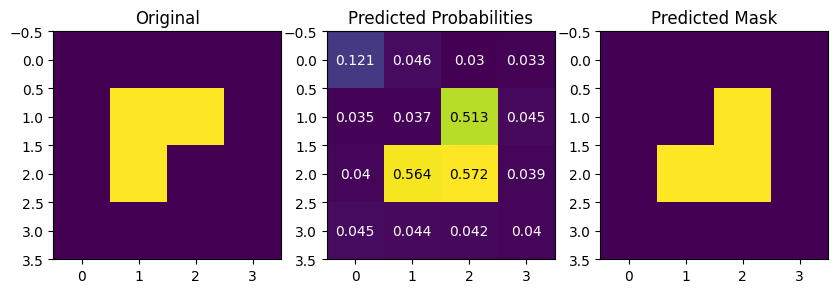

In [24]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize= (10,3*10))

ax1.imshow(dummpy_sample['labels'].squeeze(1)[0].cpu())
ax1.set_title("Original")

ax2.imshow(dummpy_sample['logits'].sigmoid().squeeze(1)[0].cpu())
for (j,i),label in np.ndenumerate(dummpy_sample['logits'].sigmoid().squeeze(1)[0].cpu()):
    if label < 0.5:
        color = 'white'
    else:
        color = 'black'
    ax2.text(i,j,round(label,3), color=color, ha='center',va='center')

ax2.set_title("Predicted Probabilities")

ax3.imshow((dummpy_sample['logits'].sigmoid() > 0.5).squeeze(1)[0].cpu())
ax3.set_title("Predicted Mask")
plt.show()

Проверяем на данном примере:

In [25]:
bce_loss_score = bce_loss(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu())
bce_true_score = bce_true(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu())
bce_torch_score = bce_torch(torch.sigmoid(dummpy_sample['logits'].cpu()), dummpy_sample['labels'].cpu().float())
bce_torch_with_logits_score = bce_torch_with_logits(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu().float())
assert np.isclose(bce_loss_score, bce_torch_score)
assert np.isclose(bce_loss_score, bce_torch_with_logits_score)
assert np.isclose(bce_true_score, bce_torch_score)
assert np.isclose(bce_true_score, bce_torch_with_logits_score)

## Шаг 4. Модель SegNet [2 балла]

Ваше задание здесь состоит в том, чтобы реализовать SegNet архитектуру.

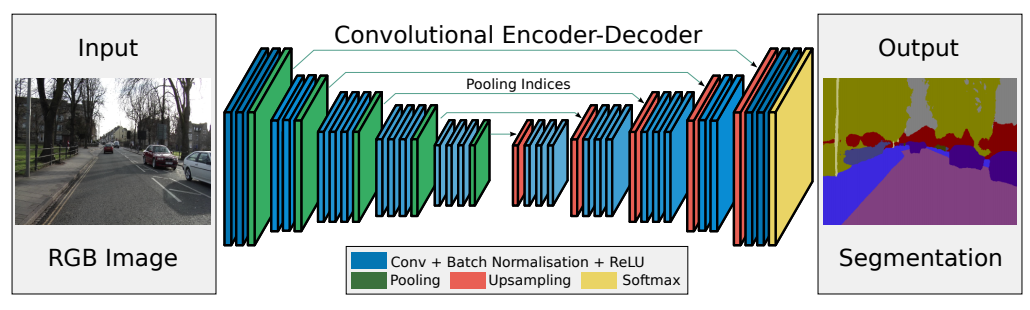

* Badrinarayanan, V., Kendall, A., & Cipolla, R. (2015). [SegNet: A deep convolutional
encoder-decoder architecture for image segmentation](https://arxiv.org/pdf/1511.00561.pdf)

In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
import torch.optim as optim
from time import time

from matplotlib import rcParams
rcParams['figure.figsize'] = (15,4)

Внимательно посмотрите из чего состоит модель и для чего выбраны те или иные блоки. Для этого скачаем и изучим feature extractor VGG-16, который лежит в основе SegNet.

In [27]:
model_vgg16 = models.vgg16(weights = models.VGG16_Weights.IMAGENET1K_V1)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 69.3MB/s]


In [28]:
model_vgg16

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

Feature extractor VGG-16 состоит из 5 блоков:
- два блока со структурой:
Conv2d -> ReLU -> Conv2d -> ReLU -> MaxPool2d
- три блока со структурой:
Conv2d -> ReLU -> Conv2d -> ReLU -> Conv2d -> ReLU -> MaxPool2d

В первом блоке - на входе три канала (по числу каналов в изображениях), которые конволюционный слой преобразует в 64 канала.

Во втором, третьем и четвертом блоках первый конволюционный слой удваивает количество каналов, а последующие конволюционные слои не меняют количество каналов.

В последнем блоке число каналов от слоя к слою не меняется.

Теперь напишем код одного блока энкодера нашей модели SegNet.  

In [29]:
# Параметрами блока будут:
# - количество каналов на входе
# - количество каналов на выходе
# - глубина блока (2 или 3, по количеству конволюционных слоев)
# - kernel_size и padding
#
class EncoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, depth, kernel_size = 3, padding = 1):
        super(EncoderBlock, self).__init__() # инициируем экземляр класса, наследующего от nn.Module
        self.layers = nn.ModuleList() # в self.layers будем добавлять слои блока
        # дальше реализуем то, что на картинке выше обозначено Conv + Batch Normalization + ReLU
        self.layers.append(nn.Conv2d(in_channels = in_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
        self.layers.append(nn.BatchNorm2d(out_channels))
        self.layers.append(nn.ReLU(inplace=True))

        # цикл for помогает использовать один код для блоков как с глубиной 2, так и с глубиной 3
        for i in range(depth-1):
            self.layers.append(nn.Conv2d(in_channels = out_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
            self.layers.append(nn.BatchNorm2d(out_channels))
            self.layers.append(nn.ReLU(inplace=True))

        self.maxpooling = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True) #добавляем MaxPool с индексами для последующего Unpooling

    # Обратите внимание: на вход метод forward() получает карту признаков (х),
    # а возвращает карту признаков и индексы для последующего Unpooling
    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        x, indices = self.maxpooling(x)
        return x, indices


По аналогии напишите код одного блока декодера.

К карте признаков на входе каждого блока примеяется nn.MaxUnpool2d с индексами из симметричного блока энкодера. Затем повторяется связка Conv + Batch Normalization + ReLU. Количество каналов меняется зеркально блокам энкодера:
- в первом блоке декодера количество каналов не меняется
- во 2-4 блоках декодера количество каналов уменьшается в 2 раза после прохождения последнего конволюционного слоя
- на выходе из последнего блока декодера 1 канал

Обратите внимание, что после последней конволюции последнего блока декодера не применяется батч-нормализация и функция активации.

In [30]:
class DecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, depth, kernel_size=3, padding=1):
        super(DecoderBlock, self).__init__()
        self.layers = nn.ModuleList()
        self.maxunpooling = nn.MaxUnpool2d(kernel_size=2, stride=2)

        self.layers.append(nn.Conv2d(in_channels, in_channels, kernel_size, padding=padding))
        self.layers.append(nn.BatchNorm2d(in_channels))
        self.layers.append(nn.ReLU(inplace=True))

        for i in range(depth - 1):
            if i == depth - 2:
                self.layers.append(nn.Conv2d(in_channels, out_channels, kernel_size, padding=padding))
                self.layers.append(nn.BatchNorm2d(out_channels))
                self.layers.append(nn.ReLU(inplace=True))
            else:
                self.layers.append(nn.Conv2d(in_channels, in_channels, kernel_size, padding=padding))
                self.layers.append(nn.BatchNorm2d(in_channels))
                self.layers.append(nn.ReLU(inplace=True))

    def forward(self, x, indices):
        x = self.maxunpooling(x, indices)
        for layer in self.layers:
            x = layer(x)
        return x

Соединим блоки энкодера и декодера в модель SegNet:

In [31]:
class SegNet(nn.Module):
    def __init__(self, in_channels=3, out_channels = 1, num_features = 64) -> None:
        super(SegNet, self).__init__()

        # Encoder
        self.encoder0 = EncoderBlock(in_channels, num_features, depth=2)
        self.encoder1 = EncoderBlock(num_features, num_features * 2, depth=2)
        self.encoder2 = EncoderBlock(num_features * 2, num_features * 4, depth=3)
        self.encoder3 = EncoderBlock(num_features * 4, num_features * 8, depth=3)

        # Encoder bottleneck - количество каналов на входе и на выходе одинаково
        self.encoder4 = EncoderBlock(8 * num_features, 8 * num_features, depth=3)

        # Decoder bottleneck
        self.decoder0 = DecoderBlock(8 * num_features, 8 * num_features, depth=3)

        # Decoder
        self.decoder1 = DecoderBlock(num_features * 8, num_features * 4, depth=3)
        self.decoder2 = DecoderBlock(num_features * 4, num_features * 2, depth=3)
        self.decoder3 = DecoderBlock(num_features * 2, num_features, depth=2)
        self.decoder4 = DecoderBlock(num_features, out_channels, depth=2)


    def forward(self, x):
        # encoder
        x, indices0 = self.encoder0(x)
        x, indices1 = self.encoder1(x)
        x, indices2 = self.encoder2(x)
        x, indices3 = self.encoder3(x)
        x, indices4 = self.encoder4(x)
        x = self.decoder0(x, indices4)
        x = self.decoder1(x, indices3)
        x = self.decoder2(x, indices2)
        x = self.decoder3(x, indices1)
        output = self.decoder4(x, indices0)
        return output  # no activation

## Шаг 5. Тренировка модели [1 балл]

Напишите функции для обучения модели.

In [32]:
from tqdm.notebook import tqdm

In [33]:
def train_single_epoch(model, criterion, optimizer, train_dataloader, device):
  model.train()

  avg_loss = 0
  for X_batch, y_batch in tqdm(train_dataloader):
      X_batch = X_batch.to(device)
      y_batch = y_batch.to(device)

      y_pred = torch.sigmoid(model(X_batch))
      loss = criterion(y_pred, y_batch)

      loss.backward()
      optimizer.step()
      optimizer.zero_grad()

      avg_loss += loss

  avg_loss /= len(train_dataloader)

  return model, avg_loss

In [34]:
def validate_after_epoch(model, criterion, dataloader, device):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            y_pred = torch.sigmoid(model(X_batch))
            loss = criterion(y_pred, y_batch)

            total_loss += loss

    avg_loss = total_loss / len(dataloader)

    return avg_loss

In [35]:
def train(model, criterion, optimizer, train_dataloader, valid_dataloader, num_epochs, device):
    train_losses = []
    valid_losses = []

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")

        model, avg_train_loss = train_single_epoch(model, criterion, optimizer, train_dataloader, device)
        train_losses.append(avg_train_loss.item())

        avg_valid_loss = validate_after_epoch(model, criterion, valid_dataloader, device)
        valid_losses.append(avg_valid_loss)

        print(f'Train Loss: {avg_train_loss:.6f} | Valid Loss: {avg_valid_loss:.6f}')

    return model, train_losses, valid_losses

In [36]:
! %env CUDA_LAUNCH_BLOCKING=1

/bin/bash: line 1: fg: no job control


Обучите модель **SegNet**. В качестве оптимайзера можно взять Adam.

In [37]:
model = SegNet().to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 50
trained_model, train_losses, valid_losses = train(
    model, criterion, optimizer,
    train_dataloader, valid_dataloader,
    num_epochs, device
)

Epoch 1/50


  0%|          | 0/4 [00:00<?, ?it/s]

Train Loss: 0.730301 | Valid Loss: 1.095795
Epoch 2/50


  0%|          | 0/4 [00:00<?, ?it/s]

Train Loss: 0.708350 | Valid Loss: 0.955077
Epoch 3/50


...

Train Loss: 0.571055 | Valid Loss: 0.545915
Epoch 49/50


  0%|          | 0/4 [00:00<?, ?it/s]

Train Loss: 0.564265 | Valid Loss: 0.560740
Epoch 50/50


  0%|          | 0/4 [00:00<?, ?it/s]

Train Loss: 0.572482 | Valid Loss: 0.573569


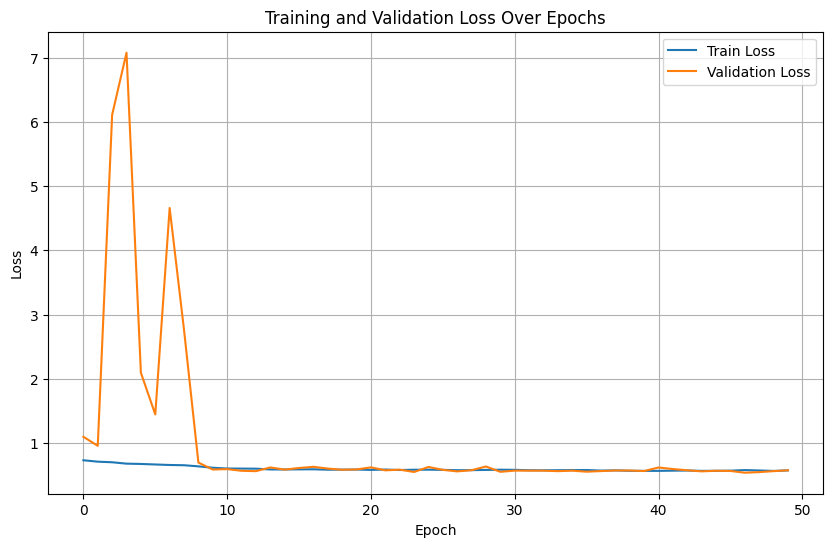

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

train_losses_cpu = [loss.item() if isinstance(loss, torch.Tensor) else loss for loss in train_losses]
valid_losses_cpu = [loss.item() if isinstance(loss, torch.Tensor) else loss for loss in valid_losses]

plt.plot(train_losses_cpu, label='Train Loss')
plt.plot(valid_losses_cpu, label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

## Шаг 6. Инференс [1 балл]

После обучения модели напишите функцию теста, воспользуйтесь лучшим чекпоинтом и протестируйте работу модели на тестовой выборке.

In [39]:
def test(model, test_dataloader, device):
    model.eval()
    total_loss = 0
    total_iou = 0

    with torch.no_grad():
        for X_batch, y_batch in tqdm(test_dataloader, desc="Testing"):
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            y_pred = torch.sigmoid(model(X_batch))

            y_pred_binary = (y_pred > 0.5).float()
            iou = iou_score(y_pred_binary, y_batch.int())
            total_iou += iou.item()

    avg_iou = total_iou / len(test_dataloader)

    return avg_iou

In [40]:
test_iou = test(trained_model, test_dataloader, device)
print(f"Test IoU: {test_iou:.6f}")

Testing:   0%|          | 0/2 [00:00<?, ?it/s]

Test IoU: 0.716420


# Задания: Мир других лоссов!

## Пробуем другие функции потерь [2 балла]

В данном разделе вам потребуется имплементировать две функции потерь: DICE и Focal loss.


### Dice Loss

**1. Dice coefficient:** Учитывая две маски $X$ и $Y$, общая метрика для измерения расстояния между этими двумя масками задается следующим образом:

$$D(X,Y)=\frac{2|X\cap Y|}{|X|+|Y|}$$

В терминах матрицы ошибок она будет считаться следующим образом:

$$D(X,Y) = \frac{2TP}{2TP + FP + FN}$$

Эта функция не является дифференцируемой, но это необходимое свойство для градиентного спуска. В данном случае мы можем приблизить его с помощью:

$$\mathcal L_D(X,Y) = 1- D(X, Y)$$

**Hints** (!):

1. Не забудьте подумать о численной нестабильности, возникающей в математической формуле при ситуации, когда $\frac{0}{0}$, т.е. вам нужно добавить очень маленькое число, например $\epsilon = 1e^{-8}$, в обе части дроби при подсчете $D(X,Y)$:

$$D(X,Y) = \frac{2TP + ϵ}{2TP + FP + FN + ϵ}$$

2. Dice метрика(!), не лосс, считается похожим образом как IoU:

    2.1. На вход вам приходят logits, т.е. значения от $-∞$ до $∞$. Их переводим в вероятности от 0 до 1 при помощи функции Sigmoid.

    2.2. Фиксируем порог, например threshold=0.5, и всему что ниже порога ставим значение 0, всему что выше 1. Получаем предсказанную маску из 0 и 1.

    2.3. Считаем TP, FP, FN

    2.4. Считаем DICE метрику по формуле

Вы можете прописать для себя функцию `dice_score()` и сравнить с результатами работы функции из библиотеки `torchmetrics`.

3. Но с метрикой есть проблема, что она не дифференцируема, и если вы захотите просто взять и прописать `dice_loss` = 1 - `dice_score`, Pytorch поругается на вас и скажет, что это недифференцируемая метрика. Чтобы посчитать dice_loss делаем следующие шаги:

    3.1. На вход вам приходят logits, т.е. значения от $-∞$ до $∞$. Их переводим в вероятности от 0 до 1 при помощи функции Sigmoid.

    3.2. Здесь нам уже не нужно фиксировать порог, мы просто работаем с вероятностями. Значения вероятностей дифференцируемы и через них будут протекать градиенты.

    3.3. Считаем TP, FP, FN также как и в Dice метрике, только вместо маски, подаем вероятности.

    3.4. Считаем DICE метрику по формуле

    3.5. Считаем лосс как Loss = 1 - DICE

Итак, давайте сначала пропишем dice_score.

In [60]:
def dice_score(logits: torch.Tensor, labels: torch.Tensor, threshold: float = 0.5):
    probabilities = torch.sigmoid(logits)
    pred_labels = (probabilities > threshold).float()

    labels = labels.float()
    tp = torch.sum(pred_labels * labels)
    fp = torch.sum(pred_labels * (1 - labels))
    fn = torch.sum((1 - pred_labels) * labels)

    epsilon = 1e-8

    score = (2 * tp + epsilon) / (2 * tp + fp + fn + epsilon)

    return score

Проверим на корректность функцию dice_score:

In [74]:
from torchmetrics.segmentation import DiceScore

dice = DiceScore(num_classes=1, average='micro').to(device)
dice(dummpy_sample['logits'].sigmoid(), dummpy_sample['labels'].to(int))

tensor(0.3158, device='cuda:0')

In [49]:
'''
если вы используете версию библиотеки 0.11.4, то можно взять torchmetrics.classification.Dice():

from torchmetrics.classification import Dice

dice = Dice(average='micro').to(device)

'''

"\nесли вы используете версию библиотеки 0.11.4, то можно взять torchmetrics.classification.Dice():\n\nfrom torchmetrics.classification import Dice\n\ndice = Dice(average='micro').to(device)\n\n"

In [71]:
# Не знаю что не так, проверял совой dice_score, он выдает верный результат для тестовых данных
dice_score(dummpy_sample['logits'], dummpy_sample['labels'])

tensor(0.6667, device='cuda:0')

In [72]:
assert dice(dummpy_sample['logits'].sigmoid(), dummpy_sample['labels'].to(int)) == dice_score(dummpy_sample['logits'], dummpy_sample['labels'])

AssertionError: 

Давайте теперь пропишем лосс и воспользуемся библиотекой `segmentation-models-pytorch`, чтобы убедиться в корректности нашей функции.

In [75]:
def dice_loss(logits: torch.Tensor, labels: torch.Tensor):
    probabilities = torch.sigmoid(logits)
    labels = labels.float()

    tp = torch.sum(probabilities * labels)
    fp = torch.sum(probabilities * (1 - labels))
    fn = torch.sum((1 - probabilities) * labels)

    epsilon = 1e-8

    dice_coeff = (2 * tp + epsilon) / (2 * tp + fp + fn + epsilon)

    loss = 1 - dice_coeff

    return loss

Проверка на корректность:

In [76]:
# !pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.2 MB/s eta 0:00:00


In [77]:
from segmentation_models_pytorch.losses import DiceLoss
dice_loss_torch = DiceLoss(mode='binary')
dice_loss_torch(dummpy_sample['logits'], dummpy_sample['labels'])

tensor(0.5756, device='cuda:0')

In [78]:
assert dice_loss_torch(dummpy_sample['logits'], dummpy_sample['labels'].to(int)) == dice_loss(dummpy_sample['logits'], dummpy_sample['labels'])

### Focal Loss

[**2. Focal loss:**](https://arxiv.org/pdf/1708.02002.pdf)

Окей, мы уже с вами умеем делать BCE loss:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

Проблема с этой потерей заключается в том, что она имеет тенденцию приносить пользу классу **большинства** (фоновому) по отношению к классу **меньшинства** ( переднему). Поэтому обычно применяются весовые коэффициенты к каждому классу:

$$\mathcal L_{wBCE}(y, \hat y) = -\sum_i \alpha_i\left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

Традиционно вес $\alpha_i$ определяется как обратная частота класса этого пикселя $i$, так что наблюдения миноритарного класса весят больше по отношению к классу большинства.


Из оригинальной статьи по [Focal Loss](https://arxiv.org/pdf/1708.02002.pdf):

$$p_t = \sigma(\hat y_i)y_i + (1 - \sigma(\hat y_i)) (1-y_i)$$

$$\mathcal L_{focal}(y, \hat y) = (1 - p_t)^{\gamma} \mathcal L_{BCE}(y_i, \hat y_i).$$

$$\mathcal L_{focal}(y, \hat y) = -\sum_i (1 - p_t)^{\gamma} \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

$$\mathcal L_{focal}(y, \hat y) = -\sum_i (1 - (\sigma(\hat y_i)y_i + (1 - \sigma(\hat y_i)) (1-y_i)))^{\gamma} \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

In [103]:
def focal_loss(y_real, y_pred, eps = 1e-8, gamma = 2):
    p = torch.sigmoid(y_pred)

    p_t = p * y_real + (1 - p) * (1 - y_real)
    log_p_t = torch.log(p_t + eps)
    ce_loss = -log_p_t
    modulating_factor = (1 - p_t) ** gamma

    loss = modulating_factor * ce_loss

    return torch.sum(loss)

Проверка корректности функции:

In [89]:
from torchvision.ops import sigmoid_focal_loss
sigmoid_focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], alpha=-1, gamma=2, reduction='sum')

tensor(3.6161, device='cuda:0')

In [105]:
focal_loss(dummpy_sample['labels'], dummpy_sample['logits'], gamma=2.0)

tensor(3.6161, device='cuda:0')

In [104]:
assert sigmoid_focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], alpha=-1, gamma=2, reduction='sum') == focal_loss(dummpy_sample['labels'], dummpy_sample['logits'], gamma=2.0)

## [BONUS] Мир сегментационных лоссов [5 баллов]

В данном блоке предлагаем вам написать одну функцию потерь самостоятельно. Для этого необходимо прочитать статью и имплементировать ее, и провести численное сравнение с предыдущими функциями.
 **ВАЖНО:** за имплементацию одного лосса выдается только один балл. Чтобы получить все 5 баллов, будет необходимо имплементировать все 5 лоссов.

* [Physiological Inspired Deep Neural Networks for Emotion Recognition](https://ieeexplore.ieee.org/stamp/stamp.jsp?arnumber=8472816&tag=1)". IEEE Access, 6, 53930-53943.

* [Boundary loss for highly unbalanced segmentation](https://arxiv.org/abs/1812.07032)

* [Tversky loss function for image segmentation using 3D fully convolutional deep networks](https://arxiv.org/abs/1706.05721)

* [Correlation Maximized Structural Similarity Loss for Semantic Segmentation](https://arxiv.org/abs/1910.08711)

* [Topology-Preserving Deep Image Segmentation](https://papers.nips.cc/paper/8803-topology-preserving-deep-image-segmentation)

## Обучите SegNet на новых лоссах

**Задание**: обучите SegNet на новых лоссах и сравните все три лосса:
*   При каком лоссе модель сходится быстрее?
*   При каком лоссе модель выдает наилучшую метрику?

Напишите развернутый ответ на вопросы.



In [111]:
num_epochs = 15

segnet_results = {}
training_times = {}

# BCE Loss
print("="*50)
print("Обучение SegNet с BCE Loss")
print("="*50)

segnet_bce = SegNet().to(device)
criterion_bce = nn.BCEWithLogitsLoss()
optimizer_bce = optim.Adam(segnet_bce.parameters(), lr=1e-3)

segnet_bce, segnet_train_losses_bce, segnet_valid_losses_bce = train(
    segnet_bce, criterion_bce, optimizer_bce,
    train_dataloader, valid_dataloader,
    num_epochs, device
)

segnet_results['BCE'] = {
    'train_losses': segnet_train_losses_bce,
    'valid_losses': segnet_valid_losses_bce,
    'model': segnet_bce
}

iou_bce = test(segnet_bce, test_dataloader, device)
print(f"\nBCE Loss - Test IoU: {iou_bce:.4f}")

# Dice Loss
print("\n" + "="*50)
print("Обучение SegNet с Dice Loss")
print("="*50)

segnet_dice = SegNet().to(device)
optimizer_dice = optim.Adam(segnet_dice.parameters(), lr=1e-3)

segnet_dice, segnet_train_losses_dice, segnet_valid_losses_dice = train(
    segnet_dice, dice_loss, optimizer_dice,
    train_dataloader, valid_dataloader,
    num_epochs, device
)

segnet_results['Dice'] = {
    'train_losses': segnet_train_losses_dice,
    'valid_losses': segnet_valid_losses_dice,
    'model': segnet_dice
}

iou_dice = test(segnet_dice, test_dataloader, device)
print(f"\nDice Loss - Test IoU: {iou_dice:.4f}")

# Focal Loss
print("\n" + "="*50)
print("Обучение SegNet с Focal Loss")
print("="*50)

segnet_focal = SegNet().to(device)
optimizer_focal = optim.Adam(segnet_focal.parameters(), lr=1e-3)

segnet_focal, segnet_train_losses_focal, segnet_valid_losses_focal = train(
    segnet_focal, focal_loss, optimizer_focal,
    train_dataloader, valid_dataloader,
    num_epochs, device
)

segnet_results['Focal'] = {
    'train_losses': segnet_train_losses_focal,
    'valid_losses': segnet_valid_losses_focal,
    'model': segnet_focal
}

iou_focal = test(segnet_focal, test_dataloader, device)
print(f"\nFocal Loss - Test IoU: {iou_focal:.4f}")

Обучение SegNet с BCE Loss
Epoch 1/15


  0%|          | 0/4 [00:00<?, ?it/s]

Train Loss: 0.820701 | Valid Loss: 0.805579
Epoch 2/15


  0%|          | 0/4 [00:00<?, ?it/s]

Train Loss: 0.811142 | Valid Loss: 0.805579
Epoch 3/15


...

Train Loss: 228400.062500 | Valid Loss: 220286.593750
Epoch 15/15


  0%|          | 0/4 [00:00<?, ?it/s]

Train Loss: 229446.187500 | Valid Loss: 219678.406250


Testing:   0%|          | 0/2 [00:00<?, ?it/s]


Focal Loss - Test IoU: 0.5624


In [113]:
def plot_training_curves_separate(losses_dict, figsize=(20, 5)):
    colors = {
        'BCE': '#2196F3',
        'Dice': '#4CAF50',
        'Focal': '#F44336'
    }

    fig, axes = plt.subplots(1, 3, figsize=figsize)

    for idx, (loss_name, data) in enumerate(losses_dict.items()):
        ax = axes[idx]

        train_losses = data['train_losses']
        valid_losses = data['valid_losses']
        test_iou = data.get('test_iou', None)

        train_np = [l.item() if torch.is_tensor(l) else l for l in train_losses]
        valid_np = [l.item() if torch.is_tensor(l) else l for l in valid_losses]

        epochs = range(1, len(train_np) + 1)

        ax.plot(epochs, train_np,
                color=colors[loss_name],
                linewidth=2,
                label='Train Loss',
                marker='o',
                markersize=3,
                markevery=max(1, len(epochs)//10))

        ax.plot(epochs, valid_np,
                color=colors[loss_name],
                linewidth=2,
                linestyle='--',
                label='Valid Loss',
                marker='s',
                markersize=3,
                markevery=max(1, len(epochs)//10))

        title = f'{loss_name} Loss'
        if test_iou is not None:
            title += f'\nTest IoU: {test_iou:.4f}'
        ax.set_title(title, fontsize=12, fontweight='bold')

        ax.set_xlabel('Epoch', fontsize=10)
        ax.set_ylabel('Loss', fontsize=10)

        ax.grid(True, alpha=0.3, linestyle='-')

        ax.legend(fontsize=9, loc='upper right')

    plt.suptitle('Comparison of Different Loss Functions',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

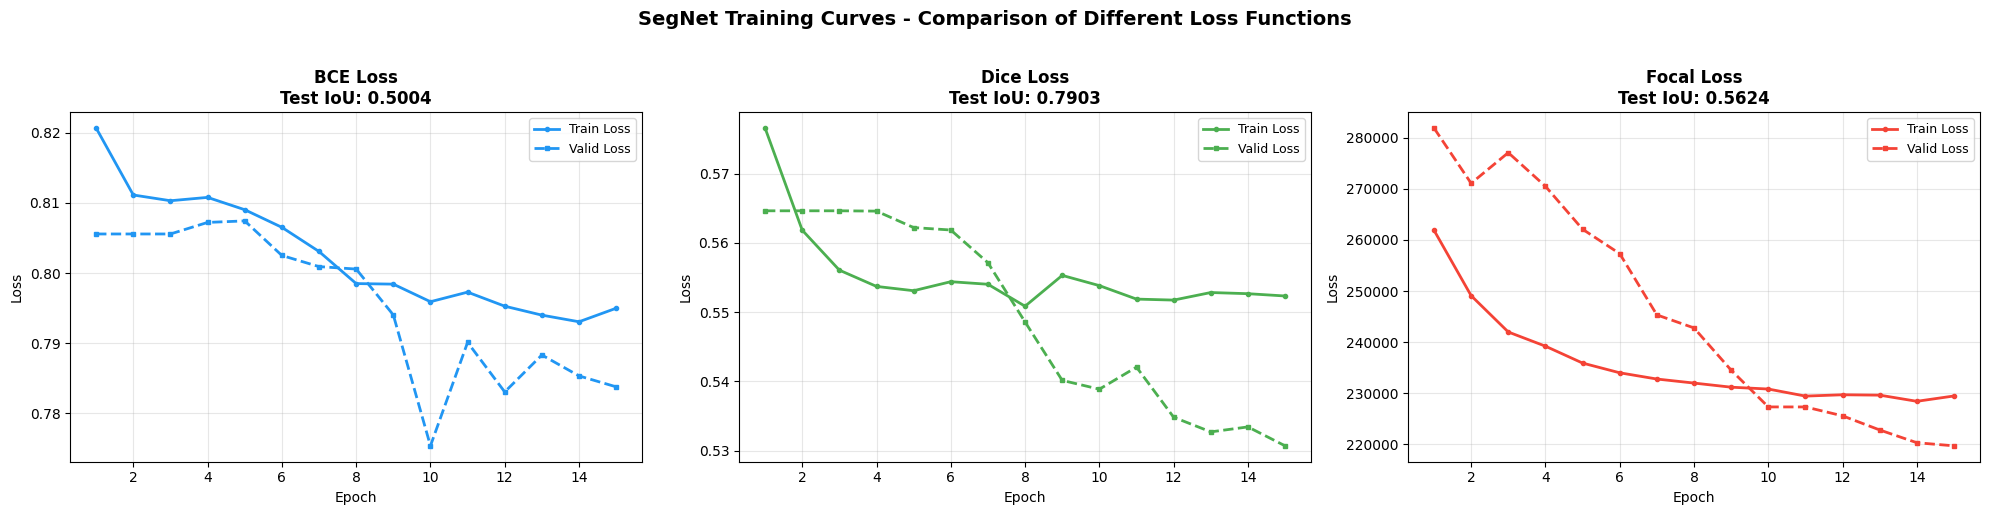

In [112]:
segnet_losses = {
    'BCE': {
        'train_losses': segnet_train_losses_bce,
        'valid_losses': segnet_valid_losses_bce,
        'test_iou': iou_bce,
    },
    'Dice': {
        'train_losses': segnet_train_losses_dice,
        'valid_losses': segnet_valid_losses_dice,
        'test_iou': iou_dice,
    },
    'Focal': {
        'train_losses': segnet_train_losses_focal,
        'valid_losses': segnet_valid_losses_focal,
        'test_iou': iou_focal,
    }
}

plot_training_curves_separate(segnet_losses)

In [ ]:
# Лучший результат получился при использовании Dice Loss, при этом лучшая сходимость у Focal Loss

# Задание: Новая модель!

## Модель U-Net [2 балла]

[**U-Net**](https://arxiv.org/abs/1505.04597) — это архитектура нейронной сети, которая получает изображение и выводит его. Первоначально он был задуман для семантической сегментации (как мы ее будем использовать), но он настолько успешен, что с тех пор используется в других контекстах. Получая на вход медицинское изображение, он выведет изображение в оттенках серого, где интенсивность каждого пикселя зависит от вероятности того, что этот пиксель принадлежит интересующей нас области.

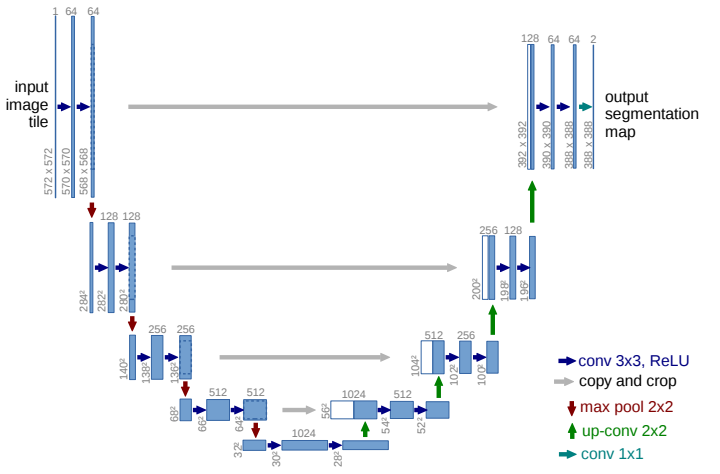

У нас в архитектуре все так же существует энкодер и декодер, как в **SegNet**, но отличительной особеностью данной модели являются *skip-conenctions*, соединяющие части декодера и энкодера. То есть для того чтобы передать на вход декодера тензор, мы конкатенируем симметричный выход с энкодера и выход предыдущего слоя декодера.

* Ronneberger, Olaf, Philipp Fischer, and Thomas Brox. "[U-Net: Convolutional networks for biomedical image segmentation.](https://arxiv.org/pdf/1505.04597.pdf)" International Conference on Medical image computing and computer-assisted intervention. Springer, Cham, 2015.

В оригинальной статье авторы не использовали padding внутри модели (это видно по тому, что размеры карты признаков уменьшаются на 2 каждый раз при движении от слоя к слою). При этом размеры входных изображений авторы единоразово увеличили при помощи mirror padding.

В этом домашнем задании вы можете применить альтернативный подход - сохранять размеры карт признаков при помощью padding = 1 во внутренних слоях.  

In [96]:
import torch.nn.functional as F
import torch.nn as nn

In [98]:
class DoubleConv(nn.Module):
    # Блок двойной свертки: Conv -> BatchNorm -> ReLU -> Conv -> BatchNorm -> ReLU
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)


Для реализации UNet вы можете написать классы блоков энкодера и декодера отдельно, как мы сделали при реализации SegNet.

In [99]:
class UNet(nn.Module):
    def __init__(self, n_class=1, in_channels=3):
        super().__init__()

        self.enc1 = DoubleConv(in_channels, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)

        self.bottleneck = DoubleConv(512, 1024)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(1024, 512)  # 512 (up) + 512 (skip)

        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(512, 256)   # 256 (up) + 256 (skip)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(256, 128)   # 128 (up) + 128 (skip)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(128, 64)    # 64 (up) + 64 (skip)

        self.final_conv = nn.Conv2d(64, n_class, kernel_size=1)

    def forward(self, x):
        enc1 = self.enc1(x)
        enc2 = self.enc2(self.pool(enc1))
        enc3 = self.enc3(self.pool(enc2))
        enc4 = self.enc4(self.pool(enc3))

        bottleneck = self.bottleneck(self.pool(enc4))

        dec4 = self.up4(bottleneck)
        dec4 = torch.cat([dec4, enc4], dim=1)
        dec4 = self.dec4(dec4)

        dec3 = self.up3(dec4)
        dec3 = torch.cat([dec3, enc3], dim=1)
        dec3 = self.dec3(dec3)

        dec2 = self.up2(dec3)
        dec2 = torch.cat([dec2, enc2], dim=1)
        dec2 = self.dec2(dec2)

        dec1 = self.up1(dec2)
        dec1 = torch.cat([dec1, enc1], dim=1)
        dec1 = self.dec1(dec1)

        output = self.final_conv(dec1)

        return output

## Обучите UNet

Задание: обучите UNet на всех трех лоссах: BCE, Dice, Focal и сравните результаты с SegNet:
*   Какая модель дает лучшие значения по метрике?
*   Какая модель дает лучшие значения по лоссам?
*   Какая модель обучается быстрее?
*   Сравните визуально результаты SegNet и UNet.

Напишите развернутый ответ на вопросы.



In [100]:
num_epochs = 20
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

unet_results = {}
segnet_results = {}

# 1. BCE Loss
print("\n" + "="*50)
print("Обучение U-Net с BCE Loss")
print("="*50)

unet_bce = UNet(n_class=1).to(device)
criterion_bce = nn.BCEWithLogitsLoss()
optimizer_bce = torch.optim.Adam(unet_bce.parameters(), lr=1e-3)

unet_bce, train_losses_bce, valid_losses_bce = train(
    unet_bce, criterion_bce, optimizer_bce,
    train_dataloader, valid_dataloader,
    num_epochs, device
)

# 2. Dice Loss
print("\n" + "="*50)
print("Обучение U-Net с Dice Loss")
print("="*50)

unet_dice = UNet(n_class=1).to(device)
optimizer_dice = torch.optim.Adam(unet_dice.parameters(), lr=1e-3)

unet_dice, train_losses_dice, valid_losses_dice = train(
    unet_dice, dice_loss, optimizer_dice,
    train_dataloader, valid_dataloader,
    num_epochs, device
)

# 3. Focal Loss
print("\n" + "="*50)
print("Обучение U-Net с Focal Loss")
print("="*50)

unet_focal = UNet(n_class=1).to(device)
optimizer_focal = torch.optim.Adam(unet_focal.parameters(), lr=1e-3)

unet_focal, train_losses_focal, valid_losses_focal = train(
    unet_focal, focal_loss, optimizer_focal,
    train_dataloader, valid_dataloader,
    num_epochs, device
)


Обучение U-Net с BCE Loss
Epoch 1/20


  0%|          | 0/4 [00:00<?, ?it/s]

Train Loss: 0.745223 | Valid Loss: 0.785362
Epoch 2/20


  0%|          | 0/4 [00:00<?, ?it/s]

Train Loss: 0.695098 | Valid Loss: 0.755552
Epoch 3/20


...

Train Loss: 208819.843750 | Valid Loss: 203140.843750
Epoch 19/20


  0%|          | 0/4 [00:00<?, ?it/s]

Train Loss: 208409.062500 | Valid Loss: 202494.750000
Epoch 20/20


  0%|          | 0/4 [00:00<?, ?it/s]

Train Loss: 208154.875000 | Valid Loss: 202128.500000


In [107]:
iou_unet_bce = test(unet_bce, test_dataloader, device)
print(f"\nBCE Loss - Test IoU: {iou_unet_bce:.4f}")

iou_unet_dice = test(unet_dice, test_dataloader, device)
print(f"\nDice Loss - Test IoU: {iou_unet_dice:.4f}")

iou_unet_focal = test(unet_focal, test_dataloader, device)
print(f"\nFocal Loss - Test IoU: {iou_unet_focal:.4f}")

Testing:   0%|          | 0/2 [00:00<?, ?it/s]


BCE Loss - Test IoU: 0.7780


Testing:   0%|          | 0/2 [00:00<?, ?it/s]


Dice Loss - Test IoU: 0.7255


Testing:   0%|          | 0/2 [00:00<?, ?it/s]


Focal Loss - Test IoU: 0.4450


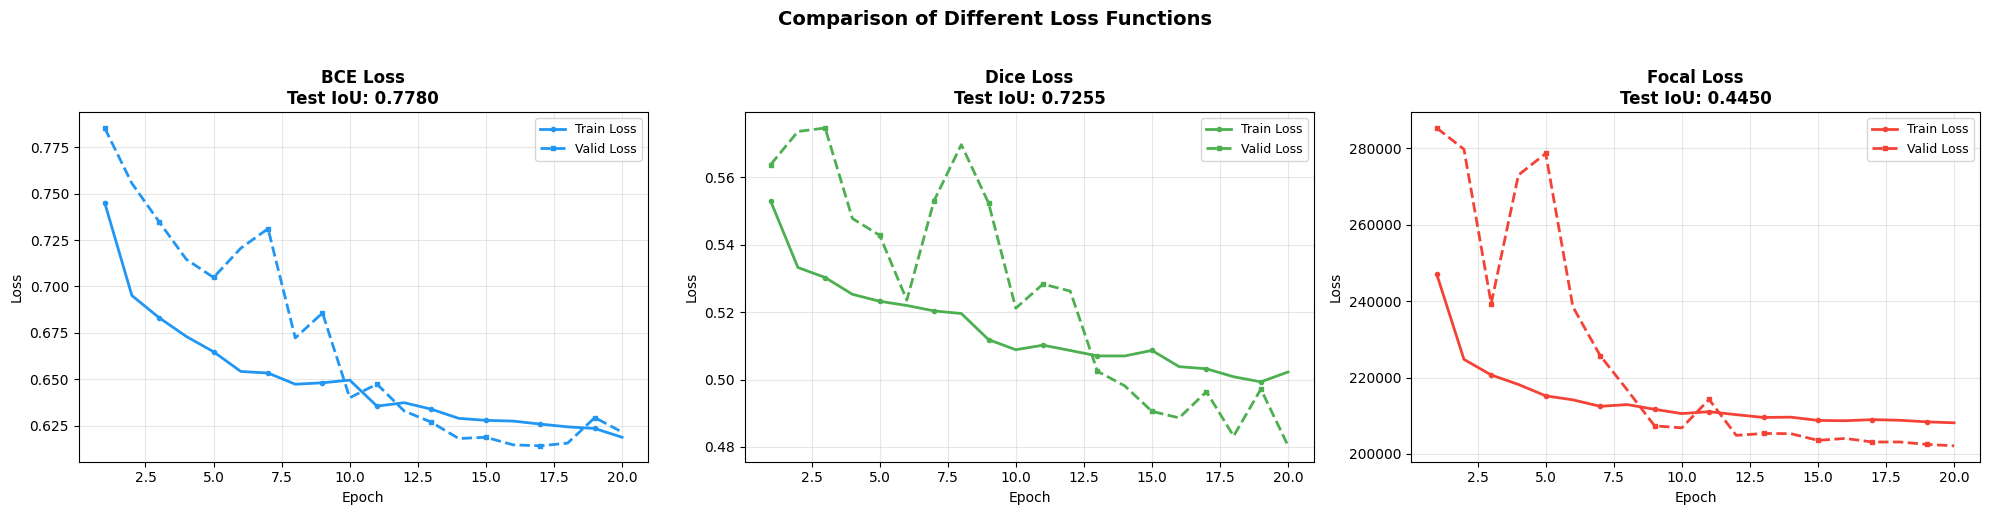

In [114]:
unet_losses = {
    'BCE': {
        'train_losses': train_losses_bce,
        'valid_losses': valid_losses_bce,
        'test_iou': iou_unet_bce,
    },
    'Dice': {
        'train_losses': train_losses_dice,
        'valid_losses': valid_losses_dice,
        'test_iou': iou_unet_dice,
    },
    'Focal': {
        'train_losses': train_losses_focal,
        'valid_losses': valid_losses_focal,
        'test_iou': iou_unet_focal,
    }
}

plot_training_curves_separate(unet_losses)

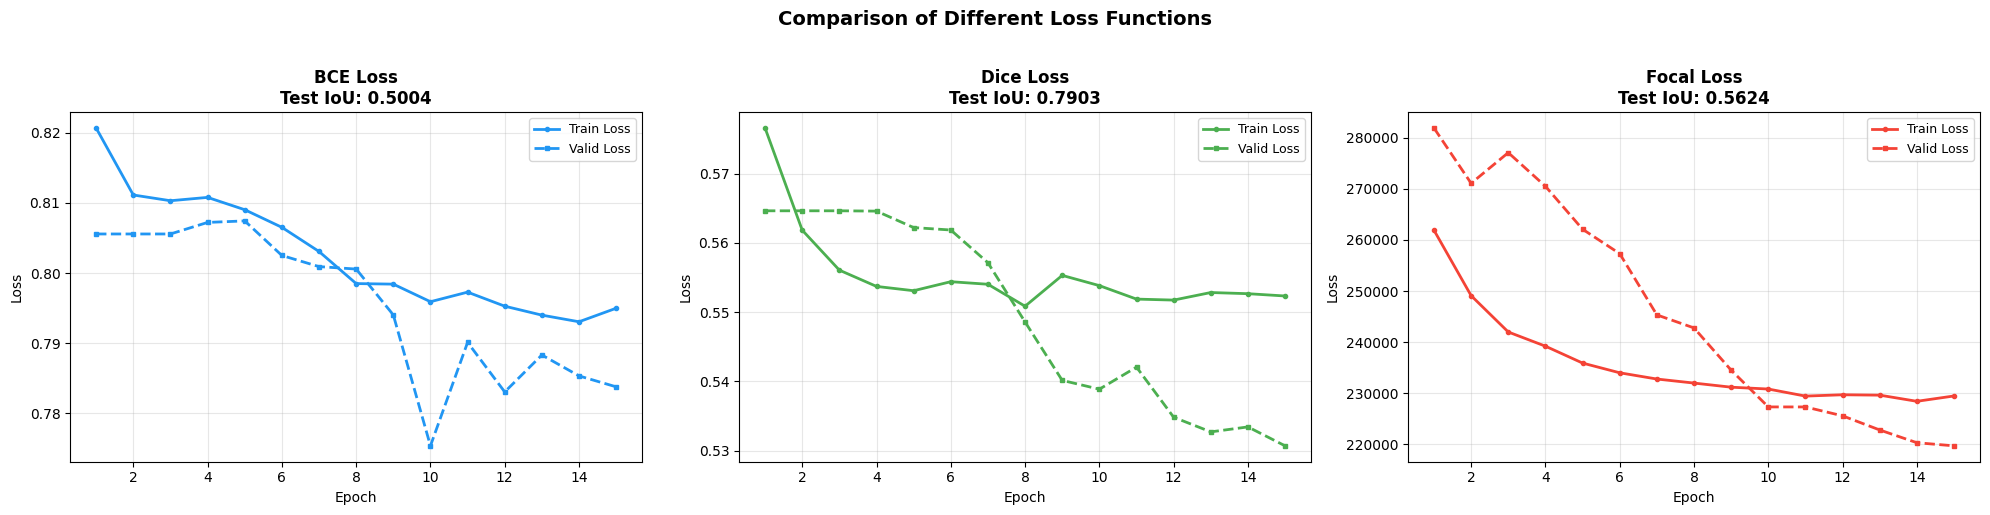

In [115]:
segnet_losses = {
    'BCE': {
        'train_losses': segnet_train_losses_bce,
        'valid_losses': segnet_valid_losses_bce,
        'test_iou': iou_bce,
    },
    'Dice': {
        'train_losses': segnet_train_losses_dice,
        'valid_losses': segnet_valid_losses_dice,
        'test_iou': iou_dice,
    },
    'Focal': {
        'train_losses': segnet_train_losses_focal,
        'valid_losses': segnet_valid_losses_focal,
        'test_iou': iou_focal,
    }
}

plot_training_curves_separate(segnet_losses)

In [ ]:
# Лучшие рузельтаты мо метрике IoU дает SegNet: максимальный результат - 0.7780 на BCE Loss у UNet
# против и 0.7903 на Dice Loss у SegNet. Но при этом это скорее еденичный случай, так как
# по графикам лоссов видно, что UNet при обучении сходится лучше. Возможно было проведено мало эпох обучения.
# Также UNet имеет более хорошие значения по лоссам.
# Также UNet однозначно лучше обучается, что видно по убывани всех лоссов во время обучения.
# Ниже представлены результаты работы обоих сетей на случайном изображении

In [117]:
import random

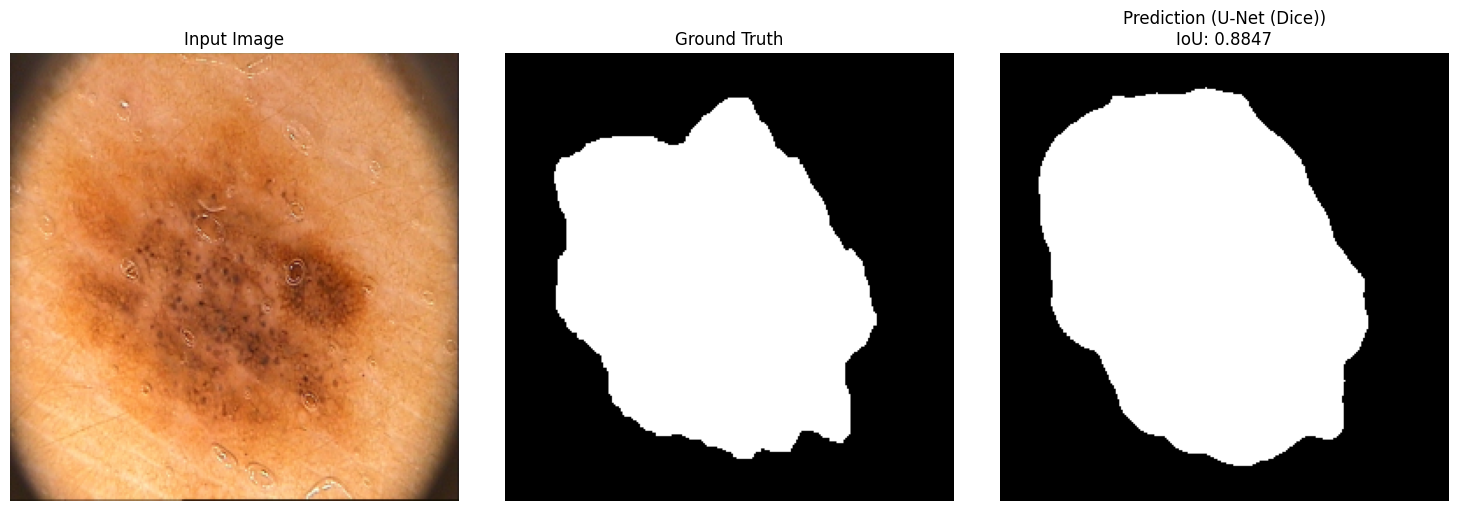

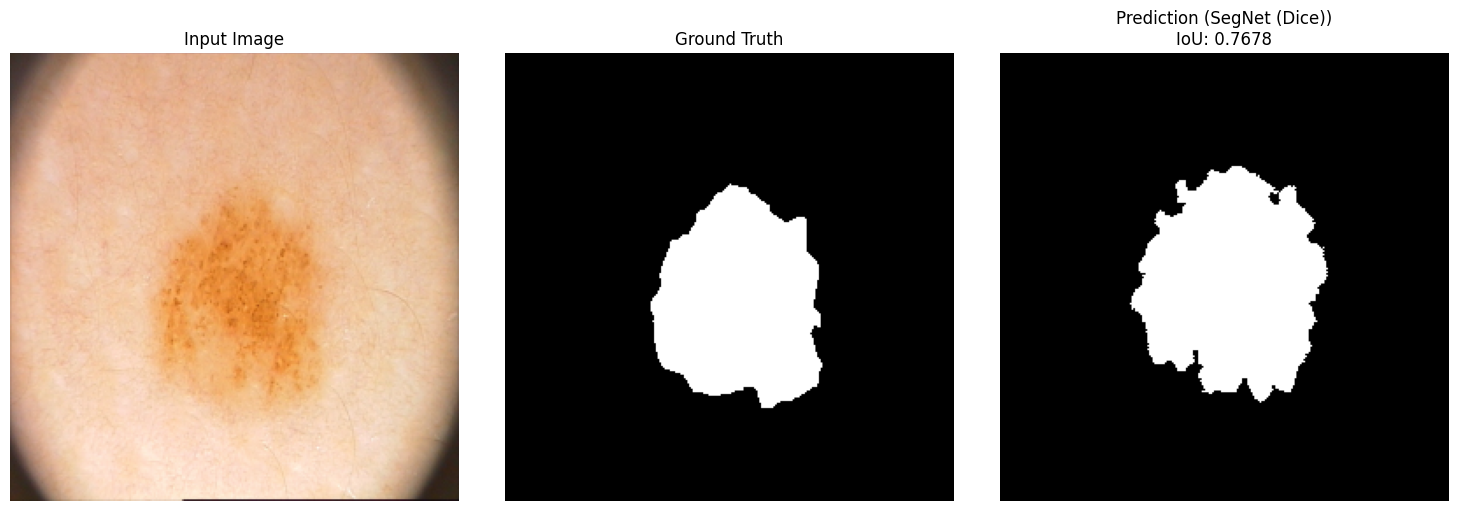

np.float64(0.7678281278209063)

In [119]:
def visualize_model_prediction(model, test_dataloader, device, model_name="Model", sample_idx=None):
    test_data = list(test_dataloader)
    batch_idx = random.randint(0, len(test_data) - 1)
    X_batch, y_batch = test_data[batch_idx]

    if sample_idx is None:
        sample_idx = random.randint(0, X_batch.shape[0] - 1)

    X_sample = X_batch[sample_idx:sample_idx+1].to(device)
    y_true = y_batch[sample_idx, 0].cpu().numpy()

    model.eval()
    with torch.no_grad():
        y_pred = torch.sigmoid(model(X_sample))
        y_pred = (y_pred[0, 0].cpu() > 0.5).float().numpy()

    img = X_sample[0].cpu().permute(1, 2, 0).numpy()
    if img.max() > 1.0:
        img = (img - img.min()) / (img.max() - img.min())

    intersection = np.sum((y_pred > 0.5) & (y_true > 0.5))
    union = np.sum((y_pred > 0.5) | (y_true > 0.5))
    iou = intersection / union if union > 0 else 0

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(img)
    axes[0].set_title('Input Image', fontsize=12)
    axes[0].axis('off')

    axes[1].imshow(y_true, cmap='gray')
    axes[1].set_title('Ground Truth', fontsize=12)
    axes[1].axis('off')

    axes[2].imshow(y_pred, cmap='gray')
    axes[2].set_title(f'Prediction ({model_name})\nIoU: {iou:.4f}', fontsize=12)
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

    return iou


visualize_model_prediction(unet_bce, test_dataloader, device, "U-Net (Dice)")

visualize_model_prediction(segnet_dice, test_dataloader, device, "SegNet (Dice)")